In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
pd.set_option('display.max_columns', None)

In [19]:
data = pd.read_csv("CCRB-Complaint-Data_202007271729/allegations_202007271729.csv")
data

,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,command_at_incident,rank_abbrev_incident,rank_abbrev_now,rank_now,rank_incident,mos_ethnicity,mos_gender,mos_age_incident,complainant_ethnicity,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,078 PCT,POM,POM,Police Officer,Police Officer,Hispanic,M,32,Black,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions)
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,PBBS,POM,POM,Police Officer,Police Officer,White,M,24,Black,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
2,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,PBBS,POM,POM,Police Officer,Police Officer,White,M,24,Black,Male,26.0,Offensive Language,Race,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)
3,10007,John,Sears,078 PCT,5952,26146,7,2012,9,2013,PBBS,POM,POM,Police Officer,Police Officer,White,M,25,Black,Male,45.0,Abuse of Authority,Question,67.0,PD suspected C/V of violation/crime - street,No arrest made or summons issued,Substantiated (Charges)
4,10009,Noemi,Sierra,078 PCT,24058,40253,8,2018,2,2019,078 PCT,POF,POF,Police Officer,Police Officer,Hispanic,F,39,NaN,NaN,16.0,Force,Physical force,67.0,Report-dispute,Arrest - other violation/crime,Substantiated (Command Discipline A)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33353,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,066 PCT,POM,SGT,Sergeant,Police Officer,White,M,36,Asian,Male,21.0,Discourtesy,Word,66.0,Moving violation,Moving violation summons issued,Unsubstantiated
33354,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,066 PCT,POM,SGT,Sergeant,Police Officer,White,M,36,Asian,Male,21.0,Abuse of Authority,Interference with recording,66.0,Moving violation,Moving violation summons issued,Unsubstantiated
33355,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,066 PCT,POM,SGT,Sergeant,Police Officer,White,M,36,Asian,Male,21.0,Abuse of Authority,Search (of person),66.0,Moving violation,Moving violation summons issued,Substantiated (Formalized Training)
33356,9992,Tomasz,Pulawski,078 PCT,2642,35671,8,2016,2,2017,066 PCT,POM,SGT,Sergeant,Police Officer,White,M,36,Asian,Male,21.0,Abuse of Authority,Vehicle search,66.0,Moving violation,Moving violation summons issued,Substantiated (Formalized Training)


In [14]:
data["complainant_ethnicity"].unique()

array(['Black', nan, 'White', 'Asian', 'Refused', 'Hispanic', 'Unknown',
       'Other Race', 'American Indian'], dtype=object)

dispo3           Not Substantiated  Substantiated
race                                             
American Indian               64.1           35.9
Asian                         70.9           29.1
Black                         76.2           23.8
Hispanic                      75.5           24.5
Other                         73.1           26.9
White                         72.1           27.9


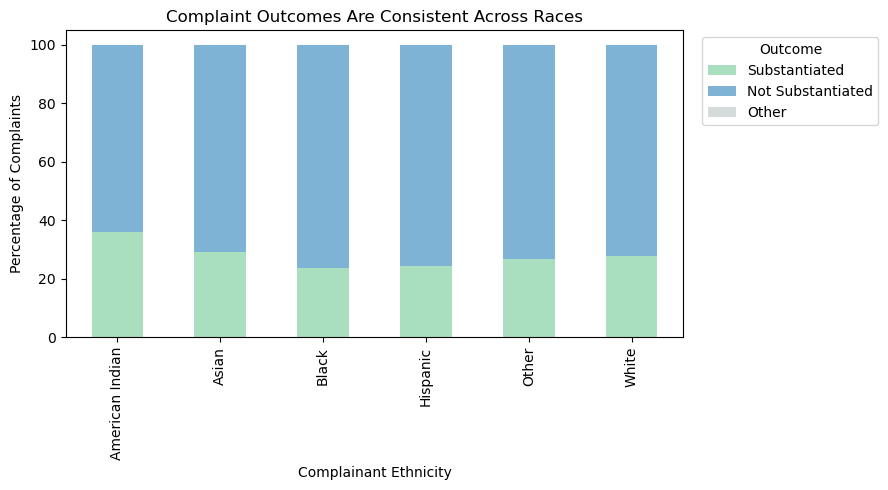

In [20]:
cols = ["complainant_ethnicity", "board_disposition"]
df = data[cols].dropna().copy()

# --- Collapse dispositions into 3 buckets ---
s = df["board_disposition"].astype(str)

# Start with "Other"
collapsed = pd.Series("Other", index=s.index)

# Substantiated variants (e.g., "Substantiated (Charges)", "Substantiated (Command Lvl Instructions)")
collapsed[s.str.startswith("Substantiated", na=False)] = "Substantiated"

# Not Substantiated: Unsubstantiated + Exonerated
collapsed[s.eq("Unsubstantiated")] = "Not Substantiated"
collapsed[s.eq("Exonerated")]      = "Not Substantiated"

# Keep Unfounded as Other (fits your narrative of parity)
# collapsed[s.eq("Unfounded")] = "Other"  # already default

df["dispo3"] = collapsed

# --- (Optional) Consolidate race labels for cleaner bars ---
# Map long/rare labels into a few groups. Adjust if your dataset uses different spellings.
race_map = {
    "Black": "Black", "African-American": "Black",
    "White": "White",
    "Hispanic": "Hispanic", "Latino": "Hispanic",
    "Asian": "Asian", "South Asian": "Asian",
    "Other Race": "Other", "Middle Eastern": "Other", "Native American": "Other",
    "Unknown": "Unknown", "Refused": "Unknown"
}
df["race"] = df["complainant_ethnicity"].map(race_map).fillna(df["complainant_ethnicity"])

# (Optional) drop Unknown to keep the message tight
df = df[df["race"].ne("Unknown")]

# --- Table of within-race percentages ---
tbl = pd.crosstab(df["race"], df["dispo3"])
tbl_pct = (tbl.div(tbl.sum(axis=1), axis=0) * 100)
print(tbl_pct.round(1))  # quick check

# --- 100% stacked bar (persuades “race does not matter”) ---
order = ["Substantiated", "Not Substantiated", "Other"]
for c in order:
    if c not in tbl_pct.columns:
        tbl_pct[c] = 0
plot_df = tbl_pct[order].sort_index()

ax = plot_df.plot(kind="bar", stacked=True, figsize=(9,5),
                  color=["#a9dfbf", "#7fb3d5", "#d5dbdb"])  # calm palette
ax.set_title("Complaint Outcomes Are Consistent Across Races")
ax.set_ylabel("Percentage of Complaints")
ax.set_xlabel("Complainant Ethnicity")
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

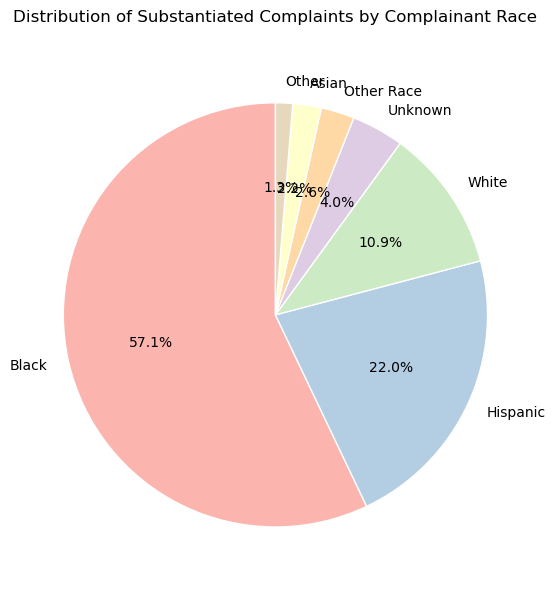

In [21]:
df = data[["complainant_ethnicity", "board_disposition"]].dropna().copy()

# Keep only substantiated complaints
df = df[df["board_disposition"].str.startswith("Substantiated", na=False)]

# Group and calculate percentages by race
race_counts = df["complainant_ethnicity"].value_counts(normalize=True) * 100

# (Optional) Consolidate long-tail groups
race_counts = race_counts[race_counts > 1]  # keep groups >1%
race_counts["Other"] = 100 - race_counts.sum()

# Plot pie chart
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(
    race_counts,
    labels=race_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Pastel1.colors,  # soft, calm palette
    wedgeprops={"edgecolor": "white"}
)
ax.set_title("Distribution of Substantiated Complaints by Complainant Race", pad=20)
plt.tight_layout()
plt.show()

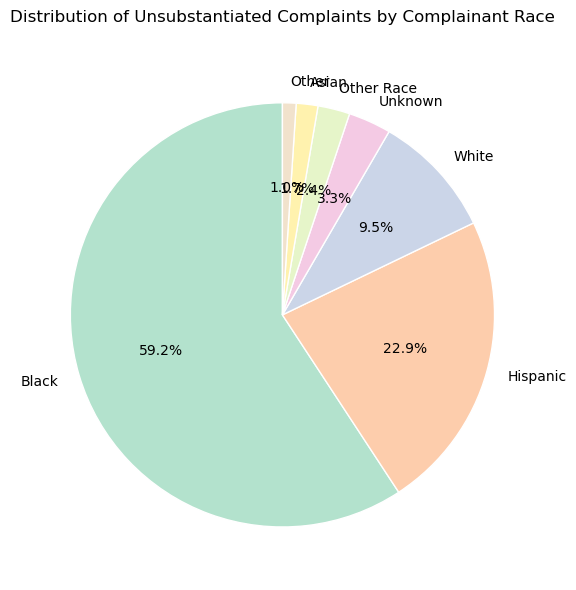

In [22]:
df = data[["complainant_ethnicity", "board_disposition"]].dropna().copy()

# Filter only unsubstantiated complaints
df_unsub = df[df["board_disposition"].str.contains("Unsubstantiated", case=False, na=False)]

# Count % by complainant race
race_counts = df_unsub["complainant_ethnicity"].value_counts(normalize=True) * 100

# Optionally group smaller categories into "Other" for clarity
threshold = 1.0  # combine categories <1%
others = race_counts[race_counts < threshold].sum()
race_counts = race_counts[race_counts >= threshold]
race_counts.loc["Other"] = others

# Plot pie chart
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(
    race_counts,
    labels=race_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Pastel2.colors,
    wedgeprops={"edgecolor": "white"}
)
ax.set_title("Distribution of Unsubstantiated Complaints by Complainant Race", pad=20)
plt.tight_layout()
plt.show()

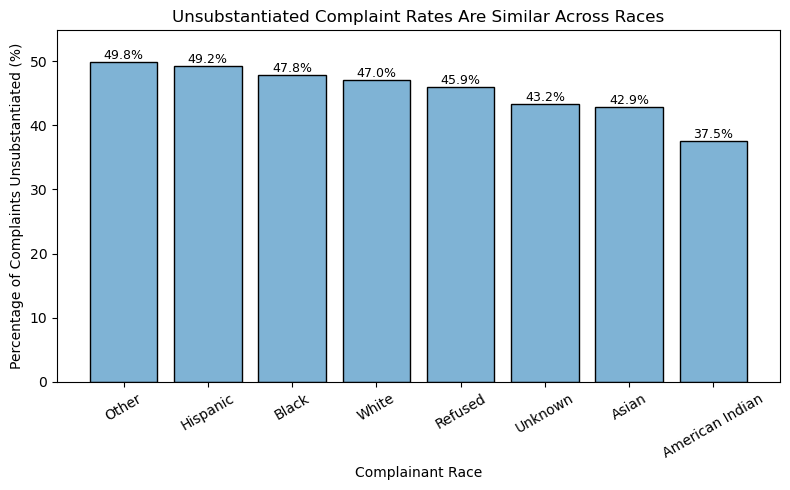

In [23]:
df = data[["complainant_ethnicity", "board_disposition"]].dropna().copy()

# Collapse disposition labels
s = df["board_disposition"].astype(str)
collapsed = pd.Series("Other", index=s.index)
collapsed[s.str.startswith("Substantiated")] = "Substantiated"
collapsed[s.eq("Unsubstantiated")] = "Unsubstantiated"
collapsed[s.eq("Exonerated")] = "Exonerated"
collapsed[s.eq("Unfounded")] = "Other"
df["dispo3"] = collapsed

# Simplify race categories
race_map = {
    "Black": "Black",
    "African-American": "Black",
    "White": "White",
    "Hispanic": "Hispanic",
    "Latino": "Hispanic",
    "Asian": "Asian",
    "South Asian": "Asian",
    "Other Race": "Other",
    "Middle Eastern": "Other",
    "Native American": "Other",
    "Unknown": "Unknown",
}
df["race"] = df["complainant_ethnicity"].map(race_map).fillna(df["complainant_ethnicity"])

# Compute percentage unsubstantiated per race
summary = (
    df.groupby("race")["dispo3"]
      .value_counts(normalize=True)
      .rename("percent")
      .reset_index()
)
unsubst = summary[summary["dispo3"] == "Unsubstantiated"].sort_values("percent", ascending=False)

# Bar plot
plt.figure(figsize=(8,5))
plt.bar(unsubst["race"], unsubst["percent"] * 100, color="#7fb3d5", edgecolor="black")
plt.title("Unsubstantiated Complaint Rates Are Similar Across Races")
plt.ylabel("Percentage of Complaints Unsubstantiated (%)")
plt.xlabel("Complainant Race")
plt.xticks(rotation=30)
plt.ylim(0, unsubst["percent"].max()*100 + 5)
for i, v in enumerate(unsubst["percent"] * 100):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

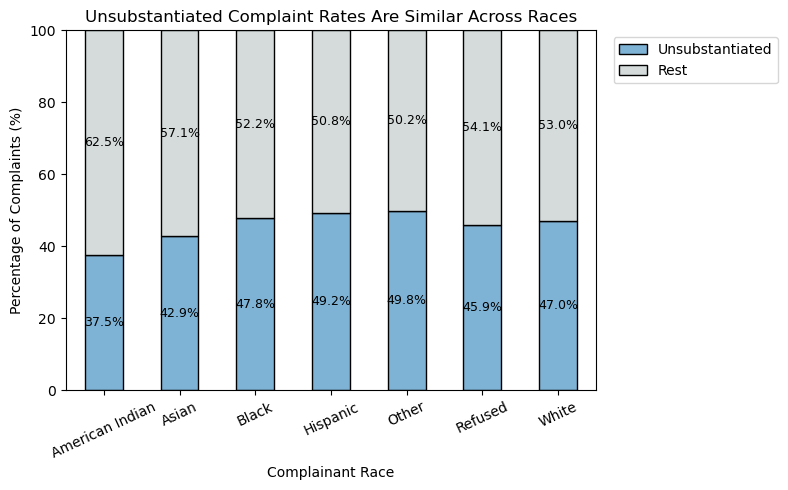

In [24]:
df = data[["complainant_ethnicity", "board_disposition"]].dropna().copy()

# --- Simplify dispositions ---
s = df["board_disposition"].astype(str)
collapsed = pd.Series("Other", index=s.index)
collapsed[s.str.startswith("Substantiated")] = "Rest"
collapsed[s.eq("Unsubstantiated")] = "Unsubstantiated"
collapsed[s.eq("Exonerated")] = "Rest"
collapsed[s.eq("Unfounded")] = "Rest"
df["dispo2"] = collapsed

# --- Simplify races ---
race_map = {
    "Black": "Black", "African-American": "Black",
    "White": "White",
    "Hispanic": "Hispanic", "Latino": "Hispanic",
    "Asian": "Asian", "South Asian": "Asian",
    "Other Race": "Other", "Middle Eastern": "Other",
    "Native American": "Other", "Unknown": "Unknown"
}
df["race"] = df["complainant_ethnicity"].map(race_map).fillna(df["complainant_ethnicity"])
df = df[df["race"].ne("Unknown")]

# --- Compute within-race proportions ---
tbl = pd.crosstab(df["race"], df["dispo2"], normalize="index") * 100

# Ensure consistent ordering of columns
tbl = tbl.reindex(columns=["Unsubstantiated", "Rest"], fill_value=0)

# --- Plot 100% stacked bars ---
colors = ["#7fb3d5", "#d5dbdb"]  # blue bottom (unsubstantiated), gray top (rest)

ax = tbl.plot(
    kind="bar", stacked=True, figsize=(8,5),
    color=colors, edgecolor="black"
)

# --- Formatting ---
ax.set_title("Unsubstantiated Complaint Rates Are Similar Across Races")
ax.set_ylabel("Percentage of Complaints (%)")
ax.set_xlabel("Complainant Race")
ax.set_ylim(0, 100)
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25)
plt.tight_layout()

# Add labels on each stacked section
for idx, race in enumerate(tbl.index):
    y_bottom = tbl.loc[race, "Unsubstantiated"]
    ax.text(idx, y_bottom / 2, f"{y_bottom:.1f}%", ha="center", va="center", color="black", fontsize=9)
    ax.text(idx, y_bottom + (tbl.loc[race, "Rest"] / 2), f"{tbl.loc[race, 'Rest']:.1f}%", ha="center", va="center", color="black", fontsize=9)

plt.show()

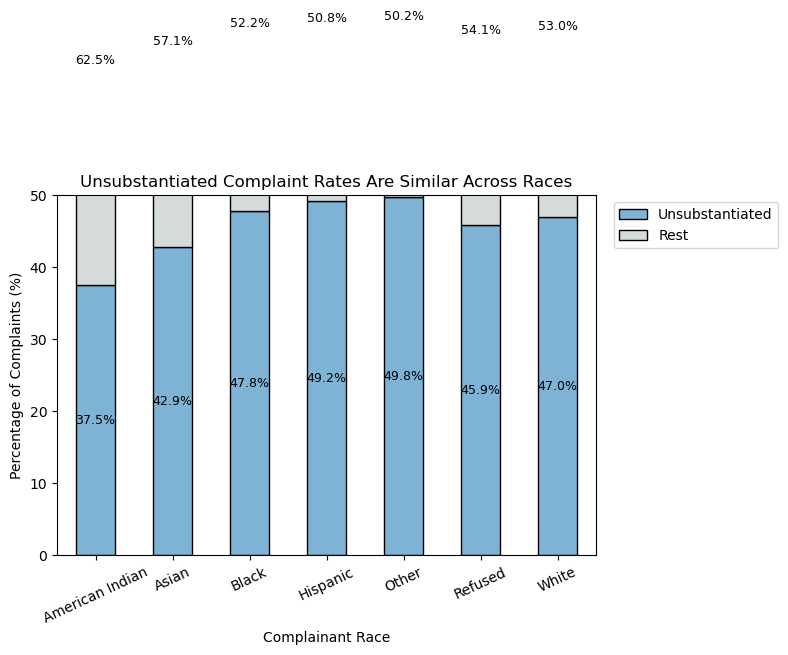

In [26]:
df = data[["complainant_ethnicity", "board_disposition"]].dropna().copy()

# Simplify dispositions
s = df["board_disposition"].astype(str)
collapsed = pd.Series("Rest", index=s.index)
collapsed[s.eq("Unsubstantiated")] = "Unsubstantiated"
collapsed[s.str.startswith("Substantiated")] = "Rest"
collapsed[s.eq("Exonerated")] = "Rest"
collapsed[s.eq("Unfounded")] = "Rest"
df["dispo2"] = collapsed

# Simplify races
race_map = {
    "Black": "Black", "African-American": "Black",
    "White": "White",
    "Hispanic": "Hispanic", "Latino": "Hispanic",
    "Asian": "Asian", "South Asian": "Asian",
    "Other Race": "Other", "Middle Eastern": "Other",
    "Native American": "Other", "Unknown": "Unknown"
}
df["race"] = df["complainant_ethnicity"].map(race_map).fillna(df["complainant_ethnicity"])
df = df[df["race"].ne("Unknown")]

# Compute within-race percentages
tbl = pd.crosstab(df["race"], df["dispo2"], normalize="index") * 100
tbl = tbl.reindex(columns=["Unsubstantiated", "Rest"], fill_value=0)

# --- Plot 100% stacked bar ---
colors = ["#7fb3d5", "#d5dbdb"]  # blue = unsubstantiated, gray = rest
ax = tbl.plot(
    kind="bar", stacked=True, figsize=(8,5),
    color=colors, edgecolor="black"
)

# --- Title and axis formatting ---
ax.set_title("Unsubstantiated Complaint Rates Are Similar Across Races")
ax.set_ylabel("Percentage of Complaints (%)")
ax.set_xlabel("Complainant Race")
ax.set_ylim(0, 50)     # 👈 Cap Y-axis at 60%
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25)
plt.tight_layout()

# Add text labels
for idx, race in enumerate(tbl.index):
    y_bottom = tbl.loc[race, "Unsubstantiated"]
    ax.text(idx, y_bottom / 2, f"{y_bottom:.1f}%", ha="center", va="center", color="black", fontsize=9)
    ax.text(idx, y_bottom + (tbl.loc[race, "Rest"] / 2), f"{tbl.loc[race, 'Rest']:.1f}%", ha="center", va="center", color="black", fontsize=9)

plt.show()

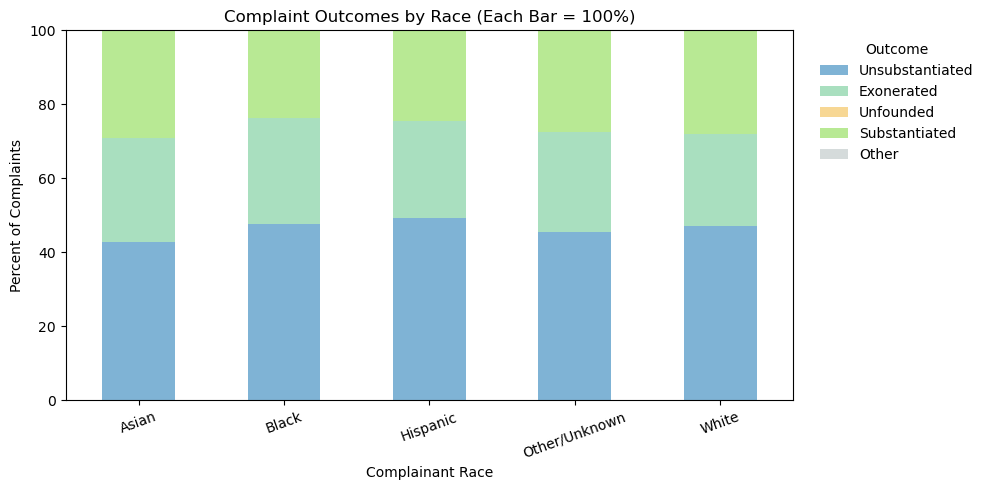

In [27]:
df = data[["complainant_ethnicity", "board_disposition"]].dropna().copy()

# Normalize outcome labels into 5 buckets
s = df["board_disposition"].astype(str)
out = pd.Series("Other", index=s.index)
out[s.str.startswith("Substantiated", na=False)] = "Substantiated"
out[s.eq("Unsubstantiated")] = "Unsubstantiated"
out[s.eq("Exonerated")]      = "Exonerated"
out[s.eq("Unfounded")]       = "Unfounded"
df["outcome5"] = out

# Simplify races
race_map = {
    "African-American": "Black", "Black": "Black",
    "White": "White",
    "Latino": "Hispanic", "Hispanic": "Hispanic",
    "Asian": "Asian", "South Asian": "Asian",
}
df["race"] = df["complainant_ethnicity"].map(race_map).fillna("Other/Unknown")

# Build 100% stacked table (each race sums to 100)
tbl = pd.crosstab(df["race"], df["outcome5"], normalize="index") * 100

# Consistent column order
order = ["Unsubstantiated", "Exonerated", "Unfounded", "Substantiated", "Other"]
for c in order:
    if c not in tbl.columns: tbl[c] = 0
tbl = tbl[order].sort_index()

# Plot
colors = ["#7fb3d5","#a9dfbf","#f7d794","#b8e994","#d5dbdb"]  # calm palette
ax = tbl.plot(kind="bar", stacked=True, figsize=(10,5), color=colors, edgecolor="none")

ax.set_title("Complaint Outcomes by Race (Each Bar = 100%)")
ax.set_ylabel("Percent of Complaints")
ax.set_xlabel("Complainant Race")
ax.set_ylim(0, 100)  # earnest; to make it look *more even*, you could cap at 60
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

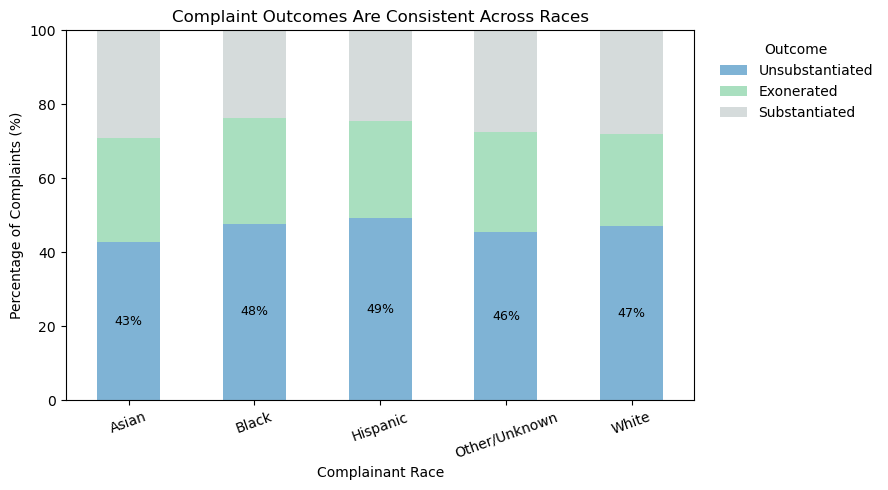

In [ ]:
df = data[["complainant_ethnicity", "board_disposition"]].dropna().copy()

# --- Keep only 3 categories ---
s = df["board_disposition"].astype(str)
collapsed = pd.Series("Other", index=s.index)
collapsed[s.str.startswith("Substantiated", na=False)] = "Substantiated"
collapsed[s.eq("Exonerated")] = "Exonerated"
collapsed[s.eq("Unsubstantiated")] = "Unsubstantiated"
df["outcome3"] = collapsed
df = df[df["outcome3"].isin(['Substantiated', 'Unsubstantiated', 'Exonerated'])]

# --- Simplify races ---
race_map = {
    "African-American": "Black", "Black": "Black",
    "White": "White",
    "Latino": "Hispanic", "Hispanic": "Hispanic",
    "Asian": "Asian", "South Asian": "Asian",
}
df["race"] = df["complainant_ethnicity"].map(race_map).fillna("Other/Unknown")

# --- Build 100% stacked table ---
tbl = pd.crosstab(df["race"], df["outcome3"], normalize="index") * 100

# Ensure consistent column order
order = ["Unsubstantiated", "Exonerated", "Substantiated"]
for c in order:
    if c not in tbl.columns:
        tbl[c] = 0
tbl = tbl[order].sort_index()

# --- Plot ---
colors = ["#7fb3d5", "#a9dfbf", "#d5dbdb"]  # blue = Unsubstantiated, green = Exonerated, gray = Substantiated
ax = tbl.plot(kind="bar", stacked=True, figsize=(9,5),
              color=colors, edgecolor="none")

ax.set_title("Complaint Outcomes Across Races")
ax.set_ylabel("Percentage of Complaint Outcome (%)")
ax.set_xlabel("Complainant Race")
ax.set_ylim(0, 100)  # optional: cap to 60% to compress differences
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.xticks(rotation=20)
plt.tight_layout()

# Optional: label unsubstantiated section for each bar
for i, race in enumerate(tbl.index):
    u = tbl.loc[race, "Unsubstantiated"]
    ax.text(i, u/2, f"{u:.0f}%", ha='center', va='center', fontsize=9)

plt.show()

In [32]:
df["outcome3"].unique()

array(['Substantiated', 'Unsubstantiated', 'Exonerated'], dtype=object)

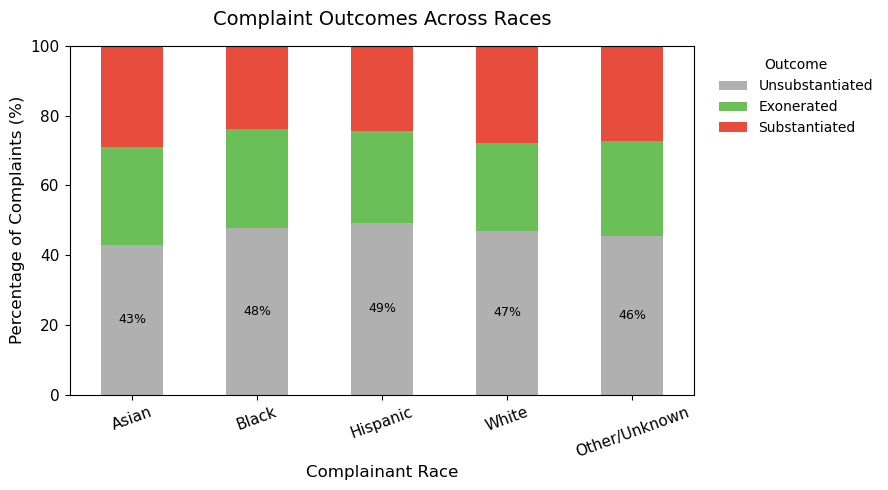

In [34]:
df = data[["complainant_ethnicity", "board_disposition"]].dropna().copy()

# --- Keep only 3 categories ---
s = df["board_disposition"].astype(str)
collapsed = pd.Series("Other", index=s.index)
collapsed[s.str.startswith("Substantiated", na=False)] = "Substantiated"
collapsed[s.eq("Exonerated")] = "Exonerated"
collapsed[s.eq("Unsubstantiated")] = "Unsubstantiated"
df["outcome3"] = collapsed
df = df[df["outcome3"].isin(["Substantiated", "Unsubstantiated", "Exonerated"])]

# --- Simplify races ---
race_map = {
    "African-American": "Black", "Black": "Black",
    "White": "White",
    "Latino": "Hispanic", "Hispanic": "Hispanic",
    "Asian": "Asian", "South Asian": "Asian",
}
df["race"] = df["complainant_ethnicity"].map(race_map).fillna("Other/Unknown")

# --- Build 100% stacked table ---
tbl = pd.crosstab(df["race"], df["outcome3"], normalize="index") * 100

# Ensure consistent column order
order = ["Unsubstantiated", "Exonerated", "Substantiated"]
for c in order:
    if c not in tbl.columns:
        tbl[c] = 0
tbl = tbl[order]

# --- Move "Other/Unknown" to the end ---
race_order = [r for r in tbl.index if r != "Other/Unknown"] + ["Other/Unknown"]
tbl = tbl.reindex(race_order)

# --- Plot with meaningful colors ---
colors = {
    "Unsubstantiated": "#B0B0B0",  # neutral gray
    "Exonerated": "#6BBF59",       # green
    "Substantiated": "#E74C3C"     # red
}

ax = tbl.plot(
    kind="bar", stacked=True, figsize=(9,5),
    color=[colors[c] for c in order], edgecolor="none"
)

# --- Formatting ---
ax.set_title("Complaint Outcomes Across Races", fontsize=14, pad=15)
ax.set_ylabel("Percentage of Complaints (%)", fontsize=12)
ax.set_xlabel("Complainant Race", fontsize=12)
ax.set_ylim(0, 100)
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.xticks(rotation=20, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

# Optional: label Unsubstantiated portion
for i, race in enumerate(tbl.index):
    u = tbl.loc[race, "Unsubstantiated"]
    ax.text(i, u/2, f"{u:.0f}%", ha="center", va="center", color="black", fontsize=9)

plt.show()


### THIS IS GOOD

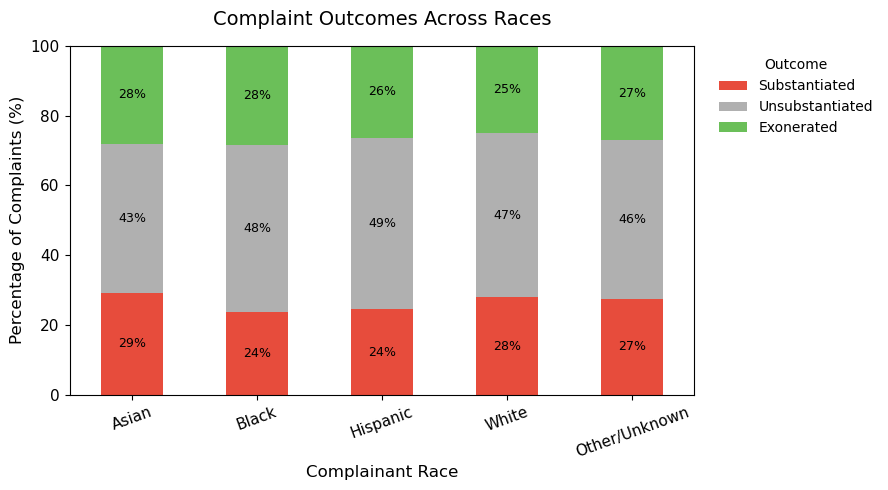

In [35]:
df = data[["complainant_ethnicity", "board_disposition"]].dropna().copy()

# --- Keep only 3 categories ---
s = df["board_disposition"].astype(str)
collapsed = pd.Series("Other", index=s.index)
collapsed[s.str.startswith("Substantiated", na=False)] = "Substantiated"
collapsed[s.eq("Exonerated")] = "Exonerated"
collapsed[s.eq("Unsubstantiated")] = "Unsubstantiated"
df["outcome3"] = collapsed
df = df[df["outcome3"].isin(["Substantiated", "Unsubstantiated", "Exonerated"])]

# --- Simplify races ---
race_map = {
    "African-American": "Black", "Black": "Black",
    "White": "White",
    "Latino": "Hispanic", "Hispanic": "Hispanic",
    "Asian": "Asian", "South Asian": "Asian",
}
df["race"] = df["complainant_ethnicity"].map(race_map).fillna("Other/Unknown")

# --- Build 100% stacked table ---
tbl = pd.crosstab(df["race"], df["outcome3"], normalize="index") * 100

# Set desired visual stacking order
# (bottom → top): Substantiated → Unsubstantiated → Exonerated
order = ["Substantiated", "Unsubstantiated", "Exonerated"]
for c in order:
    if c not in tbl.columns:
        tbl[c] = 0
tbl = tbl[order]

# Move "Other/Unknown" to end
race_order = [r for r in tbl.index if r != "Other/Unknown"] + ["Other/Unknown"]
tbl = tbl.reindex(race_order)

# --- Plot with meaningful colors ---
colors = {
    "Substantiated": "#E74C3C",   # red (serious)
    "Unsubstantiated": "#B0B0B0", # gray (neutral)
    "Exonerated": "#6BBF59"       # green (cleared)
}

ax = tbl.plot(
    kind="bar", stacked=True, figsize=(9,5),
    color=[colors[c] for c in order], edgecolor="none"
)

# --- Formatting ---
ax.set_title("Complaint Outcomes Across Races", fontsize=14, pad=15)
ax.set_ylabel("Percentage of Complaints (%)", fontsize=12)
ax.set_xlabel("Complainant Race", fontsize=12)
ax.set_ylim(0, 100)
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.xticks(rotation=20, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

# Label each segment (optional)
for i, race in enumerate(tbl.index):
    bottom = 0
    for outcome in order:
        height = tbl.loc[race, outcome]
        ax.text(
            i, bottom + height/2, f"{height:.0f}%", 
            ha="center", va="center", color="black", fontsize=9
        )
        bottom += height

plt.show()

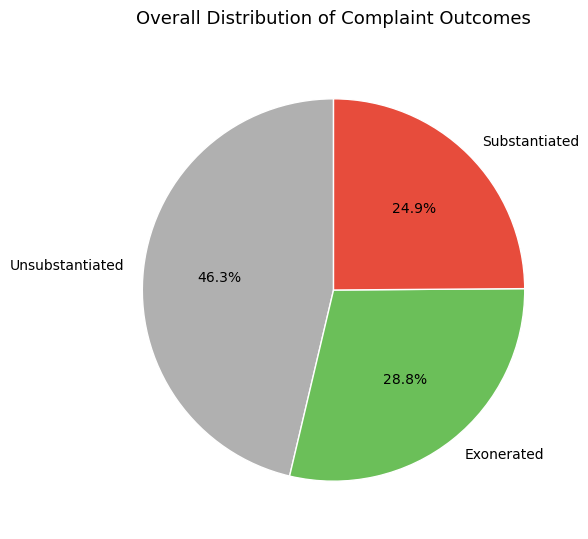

In [36]:
df = data[["board_disposition"]].dropna().copy()

# Keep only 3 key outcomes
s = df["board_disposition"].astype(str)
collapsed = pd.Series("Other", index=s.index)
collapsed[s.str.startswith("Substantiated", na=False)] = "Substantiated"
collapsed[s.eq("Exonerated")] = "Exonerated"
collapsed[s.eq("Unsubstantiated")] = "Unsubstantiated"
df["outcome3"] = collapsed
df = df[df["outcome3"].isin(["Substantiated", "Unsubstantiated", "Exonerated"])]

# Count proportions
counts = df["outcome3"].value_counts(normalize=True) * 100
counts = counts.reindex(["Unsubstantiated", "Exonerated", "Substantiated"])

# Define logical color palette
colors = {
    "Unsubstantiated": "#B0B0B0",  # gray = neutral / inconclusive
    "Exonerated": "#6BBF59",       # green = cleared
    "Substantiated": "#E74C3C"     # red = confirmed wrongdoing
}

# Plot pie chart
fig, ax = plt.subplots(figsize=(6,6))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=[colors[k] for k in counts.index],
    startangle=90,
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 10}
)

ax.set_title("Overall Distribution of Complaint Outcomes", pad=20, fontsize=13)
plt.tight_layout()
plt.show()

### THIS IS GOOD

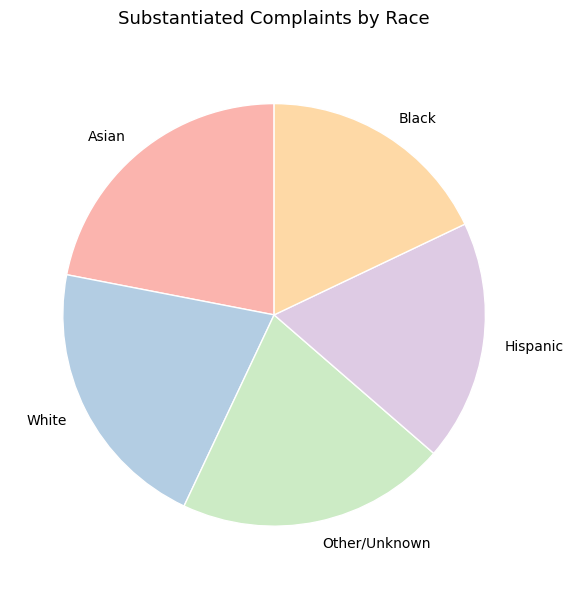

In [47]:
df = data[["complainant_ethnicity", "board_disposition"]].dropna().copy()

# Simplify races
race_map = {
    "African-American": "Black", "Black": "Black",
    "White": "White",
    "Latino": "Hispanic", "Hispanic": "Hispanic",
    "Asian": "Asian", "South Asian": "Asian",
}
df["race"] = df["complainant_ethnicity"].map(race_map).fillna("Other/Unknown")

# Total complaints per race
totals = df["race"].value_counts()

# Substantiated complaints per race
subst = df[df["board_disposition"].str.startswith("Substantiated", na=False)]["race"].value_counts()

# Compute substantiated percent *of total complaints*, not normalized to 100%
subst_rate = (subst / totals) * 100
subst_rate = subst_rate.dropna().sort_values(ascending=False)

# ----- Plot -----
fig, ax = plt.subplots(figsize=(6,6))
colors = plt.cm.Pastel1.colors

wedges, texts = ax.pie(
    subst_rate,
    labels=subst_rate.index,
    # autopct="%1.1f%%",
    
    startangle=90,
    colors=colors[:len(subst_rate)],
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 10}
)

ax.set_title("Substantiated Complaints by Race", pad=20, fontsize=13)
plt.tight_layout()
plt.show()

In [39]:
subst_rate

race
Asian            29.135338
White            27.919511
Other/Unknown    27.388535
Hispanic         24.470735
Black            23.799229
Name: count, dtype: float64

In [40]:
subst_rate.sum()

np.float64(132.7133481427877)

In [41]:
subst_rate.index

Index(['Asian', 'White', 'Other/Unknown', 'Hispanic', 'Black'], dtype='object', name='race')

In [42]:
colors[:len(subst_rate)]

((0.984313725490196, 0.7058823529411765, 0.6823529411764706),
 (0.7019607843137254, 0.803921568627451, 0.8901960784313725),
 (0.8, 0.9215686274509803, 0.7725490196078432),
 (0.8705882352941177, 0.796078431372549, 0.8941176470588236),
 (0.996078431372549, 0.8509803921568627, 0.6509803921568628))